🚀 Starting Zarr Data Analysis
🔍 Zarr Structure Inspection: /home/willse/W_Projects/Quant_Trading/live_data/hot_zarr/market_data.zarr
📊 Dataset Overview:
   Dimensions: {'day': 1, 'symbol': 5139, 'time_of_day': 1, 'quote_field': 36}
   Data variables: ['universe_membership', 'quotes_intraday']
   Coordinates: ['day', 'quote_field', 'symbol', 'time_of_day']

📅 Time Information:
   Days: 1 days
   Date range: 2025-08-24 to 2025-08-24
   Times per day: 1 ([np.str_('22:35')])

💼 Symbol Information:
   Total symbols: 5139
   First 10 symbols: [np.str_('A'), np.str_('AA'), np.str_('AACB'), np.str_('AACI'), np.str_('AACT'), np.str_('AAL'), np.str_('AAM'), np.str_('AAME'), np.str_('AAMI'), np.str_('AAOI')]

📊 Field Information:
   Quote fields: 36
      [ 0] reference.htbRate
      [ 1] reference.htbQuantity
      [ 2] extended.askPrice
      [ 3] extended.askSize
      [ 4] extended.bidPrice
      [ 5] extended.bidSize
   📍 [ 6] extended.lastPrice
      [ 7] extended.lastSize
      [ 8] extend

/tmp/ipykernel_850930/2378954288.py:235: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"   Dimensions: {dict(ds.dims)}")
/tmp/ipykernel_850930/2378954288.py:83: UserWarning: The specified chunks separate the stored chunks along dimension "symbol" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds_dask = xr.open_zarr(zarr_path, chunks={'day': 1, 'symbol': 100})


📁 Plot saved to: zarr_analysis_results.png

📈 Data Statistics:
Regular xarray:
   Mean: $43.63
   Median: $5.85
   Std Dev: $184.45
Dask xarray:
   Mean: $43.63
   Median: $5.85
   Std Dev: $184.45


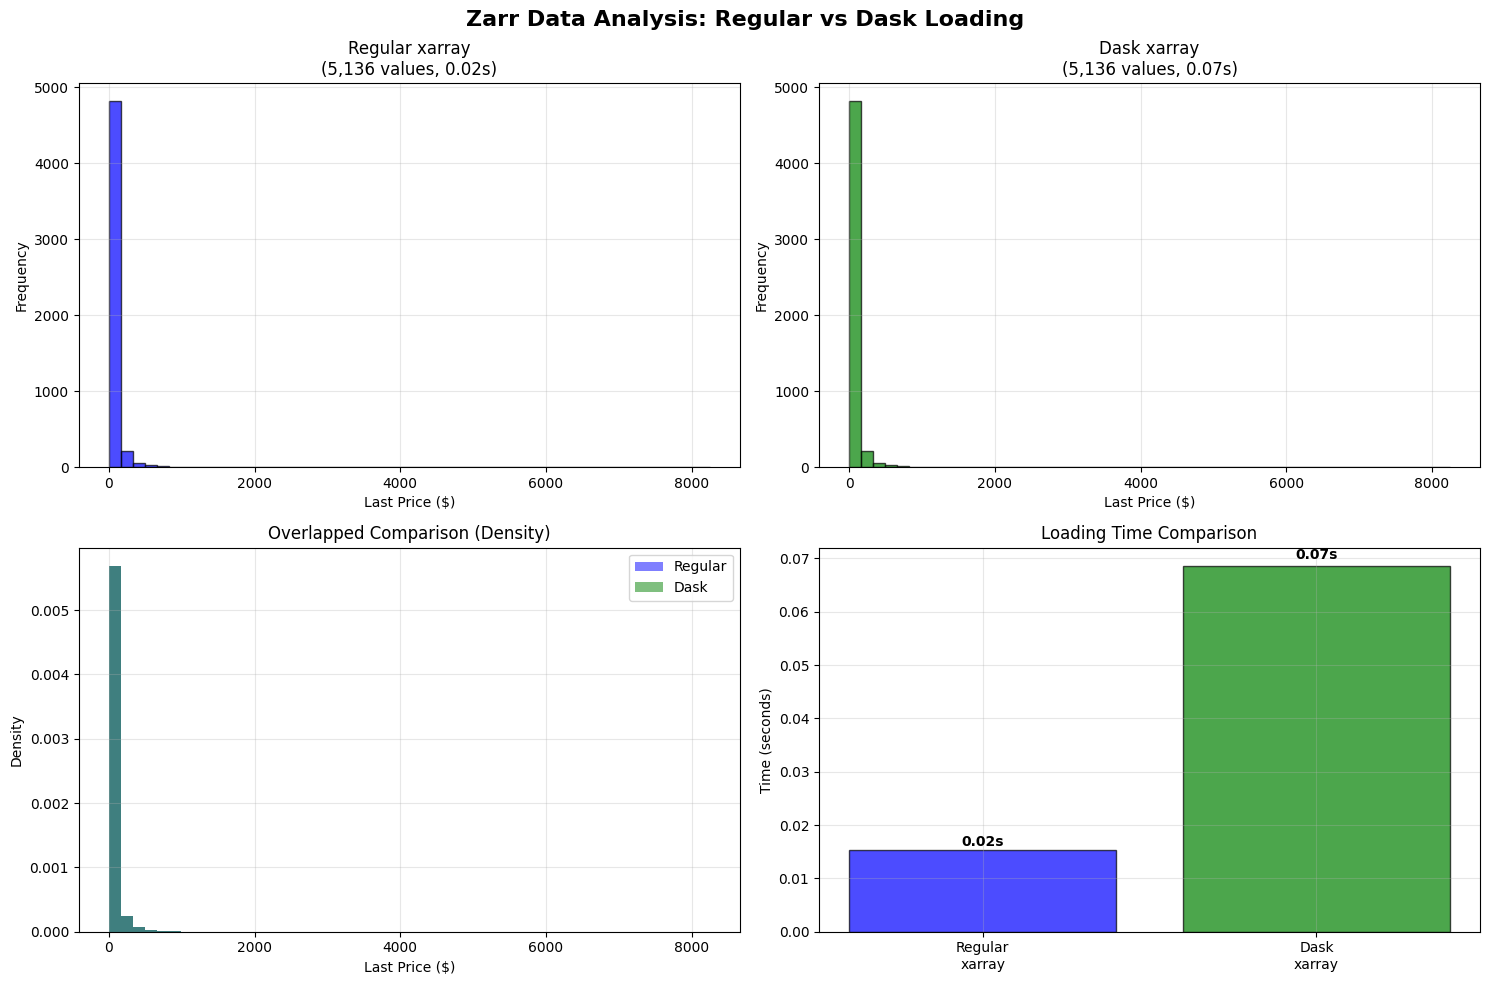


🎯 Analysis Complete!
   Data integrity: ✅ Passed
   Performance winner: Regular


In [11]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


def analyze_zarr_performance(zarr_path="~/W_Projects/Quant_Trading/live_data/hot_zarr/market_data.zarr"):
    """
    Compare performance and data integrity between regular xarray and dask loading.
    Plots histograms of lastPrice data and reports timing.
    """
    
    zarr_path = Path(zarr_path)
    
    if not zarr_path.exists():
        print(f"❌ Zarr file not found: {zarr_path}")
        return
    
    print(f"🔍 Analyzing Zarr data at: {zarr_path}")
    print("=" * 70)
    
    # Test 1: Regular xarray loading
    print("📊 Test 1: Regular xarray loading")
    start_time = time.time()
    
    try:
        # Load with regular xarray (loads everything into memory)
        ds_regular = xr.open_zarr(zarr_path)
        
        print(f"   Dataset shape: {ds_regular.dims}")
        print(f"   Variables: {list(ds_regular.data_vars.keys())}")
        print(f"   Date range: {ds_regular.day.min().values} to {ds_regular.day.max().values}")
        print(f"   Symbols: {len(ds_regular.symbol)} symbols")
        print(f"   Time points: {len(ds_regular.time_of_day)} times per day")
        
        # Find lastPrice field index
        quote_fields = ds_regular.quote_field.values
        lastprice_idx = None
        for i, field in enumerate(quote_fields):
            if 'lastPrice' in field:
                lastprice_idx = i
                lastprice_field = field
                break
        
        if lastprice_idx is None:
            print("   ⚠️  No lastPrice field found!")
            ds_regular.close()
            return
        
        print(f"   Found lastPrice field: {lastprice_field} (index {lastprice_idx})")
        
        # Extract lastPrice data
        lastprice_data_regular = ds_regular.quotes_intraday[:, :, :, lastprice_idx]
        
        # Convert to numpy and flatten (this forces computation)
        lastprice_values_regular = lastprice_data_regular.values.flatten()
        
        # Remove NaN values
        lastprice_clean_regular = lastprice_values_regular[~np.isnan(lastprice_values_regular)]
        
        load_time_regular = time.time() - start_time
        
        print(f"   ✅ Loaded {len(lastprice_clean_regular):,} valid lastPrice values")
        print(f"   📈 Price range: ${lastprice_clean_regular.min():.2f} - ${lastprice_clean_regular.max():.2f}")
        print(f"   ⏱️  Loading time: {load_time_regular:.2f} seconds")
        
        ds_regular.close()
        
    except Exception as e:
        print(f"   ❌ Error with regular loading: {e}")
        return
    
    print("\n" + "─" * 70)
    
    # Test 2: Dask-enabled loading
    print("📊 Test 2: Dask-enabled loading")
    start_time = time.time()
    
    try:
        # Load with dask chunks (lazy loading)
        ds_dask = xr.open_zarr(zarr_path, chunks={'day': 1, 'symbol': 100})
        
        print(f"   Dataset shape: {ds_dask.dims}")
        print(f"   Chunk info: {ds_dask.quotes_intraday.chunks}")
        
        # Extract lastPrice data (still lazy)
        lastprice_data_dask = ds_dask.quotes_intraday[:, :, :, lastprice_idx]
        
        # This is where dask actually computes
        computation_start = time.time()
        lastprice_values_dask = lastprice_data_dask.values.flatten()
        computation_time = time.time() - computation_start
        
        # Remove NaN values
        lastprice_clean_dask = lastprice_values_dask[~np.isnan(lastprice_values_dask)]
        
        total_time_dask = time.time() - start_time
        
        print(f"   ✅ Loaded {len(lastprice_clean_dask):,} valid lastPrice values")
        print(f"   📈 Price range: ${lastprice_clean_dask.min():.2f} - ${lastprice_clean_dask.max():.2f}")
        print(f"   ⏱️  Setup time: {computation_start - start_time:.2f} seconds")
        print(f"   ⏱️  Computation time: {computation_time:.2f} seconds")
        print(f"   ⏱️  Total time: {total_time_dask:.2f} seconds")
        
        ds_dask.close()
        
    except Exception as e:
        print(f"   ❌ Error with dask loading: {e}")
        return
    
    print("\n" + "=" * 70)
    
    # Performance comparison
    print("🏁 Performance Comparison:")
    print(f"   Regular xarray: {load_time_regular:.2f} seconds")
    print(f"   Dask xarray: {total_time_dask:.2f} seconds")
    
    if load_time_regular < total_time_dask:
        winner = "Regular xarray"
        advantage = total_time_dask / load_time_regular
    else:
        winner = "Dask xarray"
        advantage = load_time_regular / total_time_dask
    
    print(f"   🏆 Winner: {winner} ({advantage:.1f}x faster)")
    
    # Data integrity check
    print("\n🔍 Data Integrity Check:")
    if len(lastprice_clean_regular) == len(lastprice_clean_dask):
        print("   ✅ Same number of data points")
        if np.allclose(lastprice_clean_regular, lastprice_clean_dask, equal_nan=True):
            print("   ✅ Data values match exactly")
        else:
            print("   ⚠️  Data values differ slightly")
    else:
        print(f"   ⚠️  Different number of data points: {len(lastprice_clean_regular)} vs {len(lastprice_clean_dask)}")
    
    print("\n" + "=" * 70)
    
    # Create comparison plots
    print("📊 Creating comparison plots...")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Zarr Data Analysis: Regular vs Dask Loading', fontsize=16, fontweight='bold')
    
    # Plot 1: Regular xarray histogram
    ax1.hist(lastprice_clean_regular, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax1.set_title(f'Regular xarray\n({len(lastprice_clean_regular):,} values, {load_time_regular:.2f}s)')
    ax1.set_xlabel('Last Price ($)')
    ax1.set_ylabel('Frequency')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Dask histogram
    ax2.hist(lastprice_clean_dask, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax2.set_title(f'Dask xarray\n({len(lastprice_clean_dask):,} values, {total_time_dask:.2f}s)')
    ax2.set_xlabel('Last Price ($)')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Log scale comparison
    ax3.hist(lastprice_clean_regular, bins=50, alpha=0.5, color='blue', label='Regular', density=True)
    ax3.hist(lastprice_clean_dask, bins=50, alpha=0.5, color='green', label='Dask', density=True)
    ax3.set_title('Overlapped Comparison (Density)')
    ax3.set_xlabel('Last Price ($)')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Performance comparison bar chart
    methods = ['Regular\nxarray', 'Dask\nxarray']
    times = [load_time_regular, total_time_dask]
    colors = ['blue', 'green']
    
    bars = ax4.bar(methods, times, color=colors, alpha=0.7, edgecolor='black')
    ax4.set_title('Loading Time Comparison')
    ax4.set_ylabel('Time (seconds)')
    ax4.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    # Save the plot
    output_path = Path("zarr_analysis_results.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"📁 Plot saved to: {output_path}")
    
    # Show basic statistics
    print("\n📈 Data Statistics:")
    print("Regular xarray:")
    print(f"   Mean: ${np.mean(lastprice_clean_regular):.2f}")
    print(f"   Median: ${np.median(lastprice_clean_regular):.2f}")
    print(f"   Std Dev: ${np.std(lastprice_clean_regular):.2f}")
    
    print("Dask xarray:")
    print(f"   Mean: ${np.mean(lastprice_clean_dask):.2f}")
    print(f"   Median: ${np.median(lastprice_clean_dask):.2f}")
    print(f"   Std Dev: ${np.std(lastprice_clean_dask):.2f}")
    
    plt.show()
    
    return {
        'regular_time': load_time_regular,
        'dask_time': total_time_dask,
        'regular_data': lastprice_clean_regular,
        'dask_data': lastprice_clean_dask,
        'data_matches': np.allclose(lastprice_clean_regular, lastprice_clean_dask, equal_nan=True)
    }


def inspect_zarr_structure(zarr_path="~/W_Projects/Quant_Trading/live_data/hot_zarr/market_data.zarr"):
    """
    Quick inspection of zarr structure without loading all data.
    """
    zarr_path = Path(zarr_path)
    
    if not zarr_path.exists():
        print(f"❌ Zarr file not found: {zarr_path}")
        return
    
    print(f"🔍 Zarr Structure Inspection: {zarr_path}")
    print("=" * 50)
    
    try:
        # Open without loading data
        ds = xr.open_zarr(zarr_path, chunks={})
        
        print("📊 Dataset Overview:")
        print(f"   Dimensions: {dict(ds.dims)}")
        print(f"   Data variables: {list(ds.data_vars.keys())}")
        print(f"   Coordinates: {list(ds.coords.keys())}")
        
        print("\n📅 Time Information:")
        print(f"   Days: {len(ds.day)} days")
        print(f"   Date range: {pd.to_datetime(ds.day.values[0]).strftime('%Y-%m-%d')} to {pd.to_datetime(ds.day.values[-1]).strftime('%Y-%m-%d')}")
        print(f"   Times per day: {len(ds.time_of_day)} ({list(ds.time_of_day.values)})")
        
        print("\n💼 Symbol Information:")
        print(f"   Total symbols: {len(ds.symbol)}")
        print(f"   First 10 symbols: {list(ds.symbol.values[:10])}")
        
        print("\n📊 Field Information:")
        print(f"   Quote fields: {len(ds.quote_field)}")
        quote_fields = ds.quote_field.values
        for i, field in enumerate(quote_fields):
            marker = "📍" if 'lastPrice' in field else "  "
            print(f"   {marker} [{i:2d}] {field}")
        
        if 'fundamentals_daily' in ds:
            print(f"\n💰 Fundamental fields: {len(ds.fundamental_field)}")
            for i, field in enumerate(ds.fundamental_field.values):
                print(f"     [{i:2d}] {field}")
        
        print("\n💾 Data Storage Info:")
        for var_name, data_var in ds.data_vars.items():
            print(f"   {var_name}: {data_var.shape} ({data_var.dtype})")
            if hasattr(data_var, 'chunks'):
                print(f"     Chunks: {data_var.chunks}")
        
        ds.close()
        
    except Exception as e:
        print(f"❌ Error inspecting zarr: {e}")


def quick_sample_data(zarr_path="~/W_Projects/Quant_Trading/live_data/hot_zarr/market_data.zarr", n_symbols=5):
    """
    Quick sample of actual data values for verification.
    """
    zarr_path = Path(zarr_path)
    
    if not zarr_path.exists():
        print(f"❌ Zarr file not found: {zarr_path}")
        return
    
    print(f"📋 Quick Data Sample: {zarr_path}")
    print("=" * 50)
    
    try:
        ds = xr.open_zarr(zarr_path)
        
        # Get recent data from last day and time
        last_day = ds.day[-1]
        last_time = ds.time_of_day[-1]
        
        print(f"Sampling from: {pd.to_datetime(last_day.values).strftime('%Y-%m-%d')} {last_time.values}")
        
        # Sample a few symbols
        sample_symbols = ds.symbol.values[:n_symbols]
        
        # Get lastPrice field index
        quote_fields = ds.quote_field.values
        lastprice_idx = None
        for i, field in enumerate(quote_fields):
            if 'lastPrice' in field:
                lastprice_idx = i
                break
        
        if lastprice_idx is None:
            print("❌ No lastPrice field found")
            ds.close()
            return
        
        print(f"\n📊 Sample lastPrice data for {n_symbols} symbols:")
        print("-" * 40)
        
        for symbol in sample_symbols:
            # Get universe membership
            is_member = ds.universe_membership.sel(day=last_day, symbol=symbol).values
            
            # Get last price
            last_price = ds.quotes_intraday.sel(
                day=last_day, 
                time_of_day=last_time, 
                symbol=symbol, 
                quote_field=quote_fields[lastprice_idx]
            ).values
            
            membership_status = "✅ Active" if is_member else "❌ Inactive"
            price_display = f"${last_price:.2f}" if not np.isnan(last_price) else "No data"
            
            print(f"{symbol:8s}: {price_display:>10s} ({membership_status})")
        
        ds.close()
        
    except Exception as e:
        print(f"❌ Error sampling data: {e}")


if __name__ == "__main__":

    data_dir ="~/W_Projects/Quant_Trading/live_data/hot_zarr/market_data.zarr"
    data_dir = Path(data_dir).expanduser()
    
    # Run all analysis
    print("🚀 Starting Zarr Data Analysis")
    print("=" * 70)
    
    # First, inspect the structure
    inspect_zarr_structure(data_dir)
    
    print("\n")
    
    # Quick sample
    quick_sample_data(data_dir)
    
    print("\n")
    
    # Performance comparison
    results = analyze_zarr_performance(data_dir)
    
    if results:
        print("\n🎯 Analysis Complete!")
        print(f"   Data integrity: {'✅ Passed' if results['data_matches'] else '❌ Failed'}")
        print(f"   Performance winner: {'Regular' if results['regular_time'] < results['dask_time'] else 'Dask'}")